In [787]:
# Importando Librerias
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [788]:
'''
  Generar datos de una apartamento, tamaño m2, numero de habitaciones, antiguedad, Barrio y precio
    Variables x : tamaño_m2, numero_habitaciones y antiguedad, Barrio
    Varible y: precio a la que se vende el apartamento
'''

cantidad_datos = 20

datos_casas = {
    'tamano_m2': np.random.randint(50, 100, cantidad_datos),
    'numero_habitaciones': np.random.randint(1, 5, cantidad_datos),
    'antiguedad': np.random.randint(1, 10, cantidad_datos),
    'precio': np.random.randint(1000, 5000, cantidad_datos),
    # 'Barrio': np.random.choice(['Barranquilla', 'villa country', 'Los alpes'], cantidad_datos)
}


df = pd.DataFrame(datos_casas)
df.head(10)


,tamano_m2,numero_habitaciones,antiguedad,precio
0,80,4,1,2351
1,99,3,9,4952
2,95,3,2,3505
3,91,4,6,4460
4,55,4,7,4256
5,87,3,1,3494
6,86,1,5,3800
7,64,1,9,4629
8,88,2,9,3791
9,66,1,7,1922


In [789]:
print(df.shape)

(20, 4)


In [790]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   tamano_m2            20 non-null     int64
 1   numero_habitaciones  20 non-null     int64
 2   antiguedad           20 non-null     int64
 3   precio               20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes
None


In [791]:
print(df.describe())

       tamano_m2  numero_habitaciones  antiguedad       precio
count  20.000000            20.000000   20.000000    20.000000
mean   75.250000             2.500000    5.050000  3221.100000
std    16.260624             1.192079    3.068945  1050.289078
min    51.000000             1.000000    1.000000  1697.000000
25%    60.500000             1.000000    2.000000  2338.750000
50%    79.000000             3.000000    5.500000  3437.000000
75%    88.750000             3.250000    8.000000  3914.000000
max    99.000000             4.000000    9.000000  4952.000000


In [792]:
# EDA ( Exploratory Data Analysis )

# numero_habitaciones, si es negativo ponerle 0
df['numero_habitaciones'] = df['numero_habitaciones'].apply(lambda x: 0 if x < 0 else x)

# antiguedad, si es negativo ponerle 0
df['antiguedad'] = df['antiguedad'].apply(lambda x: 0 if x < 0 else x)

# Barrio, si es vacio eliminarlo del dataset
# df = df.dropna(subset=['Barrio'])


print(df.head(10))


   tamano_m2  numero_habitaciones  antiguedad  precio
0         80                    4           1    2351
1         99                    3           9    4952
2         95                    3           2    3505
3         91                    4           6    4460
4         55                    4           7    4256
5         87                    3           1    3494
6         86                    1           5    3800
7         64                    1           9    4629
8         88                    2           9    3791
9         66                    1           7    1922


In [793]:
# Separar las variables x e y
x = df[['tamano_m2', 'numero_habitaciones', 'antiguedad']]
y = df['precio']

# Separar datos de entrenamiento y prueba ( 80 - 20)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(16, 3)
(4, 3)
(16,)
(4,)


In [794]:
# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(x_train, y_train)


# Parametros del modelo y = mx + b
print(modelo.coef_)
print(modelo.intercept_)

for feature, coef in zip(x.columns, modelo.coef_):
    print(f"{feature}: {coef}")

# y = -463.6509643301975x + -15937.056056559057x2 + -2178.505223769782x3 + 550157.3182952078

[ 24.39090662 232.42864468  75.46664172]
517.0559377185305
tamano_m2: 24.390906620126586
numero_habitaciones: 232.4286446824189
antiguedad: 75.4666417232813


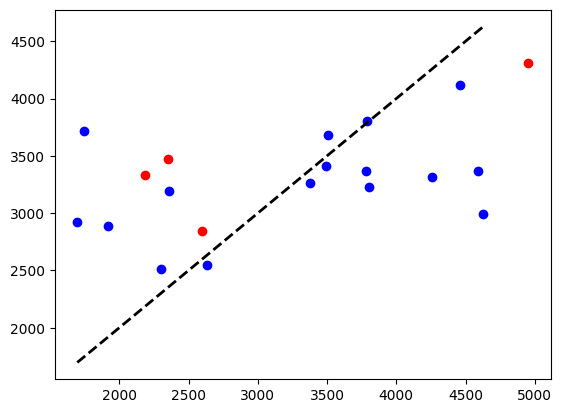

In [795]:
# Hacer las predicciones

y_pred_train = modelo.predict(x_train)
y_pred_test = modelo.predict(x_test)


# Mostrar de manera visual
plt.scatter(y_train, y_pred_train, c='blue', label='Datos de entrenamiento')
plt.scatter(y_test, y_pred_test, c='red', label='Datos de prueba')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=2)


In [796]:
# Evaluar Modelo
r2      =  r2_score(y_test, y_pred_test)
r2_test =  r2_score(y_train, y_pred_train)

mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)

print(f"R2: {r2}")
print(f"R2_test: {r2_test}")
print(f"MSE: {mse}")
print(f"MAE: {mae}")


R2: 0.39602093982287856
R2_test: 0.1829822387114931
MSE: 763729.8229028633
MAE: 789.6283651244439


In [797]:
# Ejemplo
casa_nueva = pd.DataFrame({'tamano_m2': [120], 'numero_habitaciones': [3], 'antiguedad': [5]})
precio_predicho = modelo.predict(casa_nueva)

print(f"El precio estimado de la casa es: {precio_predicho[0]}")

El precio estimado de la casa es: 4518.583874797383
